# 0DTE nearest-OTM call + put, 15:30 → 16:00

One trade per expiration day. At 15:30 ET, "ATM" means the **nearest
out-of-the-money** legs:

- call: smallest listed $K_c \ge S$ with a live mid
- put: largest listed $K_p \le S$ with a live mid

If $S$ sits on a strike those are the same $K$ (a straddle); otherwise it is
a one-strike-wide strangle. Cash settlement uses the official S&P 500 close
from yfinance (`^GSPC`): call $\max(S_{\mathrm{close}}-K_c,0)$, put
$\max(K_p-S_{\mathrm{close}},0)$.

Signal is remaining RV minus remaining IV in variance space:
$s=\widehat{RV}-(\mathrm{IV}_{\mathrm{hourly}}/\sqrt{2})^2$, with
$\widehat{RV}=(m^2+\hat\sigma^2)B$ the causal second-order map from
`yhat`. The book that survives the variants below is **always short**,
with optional unit-median $|\mathrm{VRP}|$ size. Long-short volatility $\pm 1$ is a
control. Vol-space maps ($\hat y\sqrt{B}$, $m\sqrt{B}$) live in
`atm_straddle_volmap.ipynb`.

Every cell reads from `data/` (or from a frame the previous cell just built).
Print the table before using it.

In [1]:
import hashlib
import os
from pathlib import Path
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf

def find_repo(start: Path) -> Path:
    for q in [start.resolve(), *start.resolve().parents]:
        if (q / "data" / "spxw_chain.parquet").exists():
            return q
    raise FileNotFoundError("repo root not found")

REPO = find_repo(Path.cwd())
OUT = REPO / "results" / "atm_straddle_0dte_1530"
OUT.mkdir(parents=True, exist_ok=True)
# derived-input cache: every entry is keyed on the source file's
# size+mtime (and the request), so a changed input can never serve a
# stale hit. Delete the directory to force a cold rebuild.
CACHE = OUT / "cache"
CACHE.mkdir(parents=True, exist_ok=True)
print("repo:", REPO)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 24)
pd.set_option("display.float_format", lambda x: f"{x: .6f}")


repo: C:\Users\james\CC Allowed\harxhar-clean


## 1. Load the chain (15:30 and 16:00 ET only)

File: `data/spxw_chain.parquet`. The file has every 30-minute stamp; this
strategy needs 15:30 (entry quotes). 16:00 chain stamps are kept only to
compare the tape underlying against the official close. First read
`timestamp` and keep those two Eastern clocks; then load the remaining
columns for those stamps only.

In [2]:
path = REPO / "data" / "spxw_chain.parquet"
COLS = [
    "expiration",
    "timestamp",
    "strike",
    "cp",
    "bid",
    "ask",
    "mid",
    "underlying_price",
    "impl_volatility",
]
_st = os.stat(path)
_ck = CACHE / f"chain_15301600_{_st.st_size}_{_st.st_mtime_ns}.parquet"
if _ck.exists():
    chain = pd.read_parquet(_ck)
    print(f"cache hit {_ck.name} (source size+mtime matched; "
          "full-file stamp scan skipped)")
else:
    ts = pd.to_datetime(pd.read_parquet(path, columns=["timestamp"])["timestamp"], utc=True)
    et = ts.dt.tz_convert("America/New_York")
    keep = ts[
        ((et.dt.hour == 15) & (et.dt.minute == 30)) | ((et.dt.hour == 16) & (et.dt.minute == 0))
    ].unique()
    print("unique timestamps in file", ts.nunique())
    print("15:30/16:00 ET stamps kept", len(keep))
    del ts, et
    chain = pd.read_parquet(path, columns=COLS, filters=[("timestamp", "in", list(keep))])
    chain["timestamp"] = pd.to_datetime(chain["timestamp"], utc=True)
    chain["expiration"] = pd.to_datetime(chain["expiration"])
    chain["cp"] = chain["cp"].astype(str).str.upper().str[0]
    for _old in CACHE.glob("chain_15301600_*.parquet"):
        _old.unlink()
    chain.to_parquet(_ck)
print("rows", f"{len(chain):,}")
print("columns", list(chain.columns))
print("timestamp", chain["timestamp"].min(), "->", chain["timestamp"].max())
print("expirations", chain["expiration"].nunique())
print(chain.head(3))


cache hit chain_15301600_77439812_1786671584951439500.parquet (source size+mtime matched; full-file stamp scan skipped)
rows 1,171,254
columns ['expiration', 'timestamp', 'strike', 'cp', 'bid', 'ask', 'mid', 'underlying_price', 'impl_volatility']
timestamp 2020-01-03 20:30:00+00:00 -> 2025-12-31 21:00:00+00:00
expirations 1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000


## 2. Clocks and 0DTE flag

Vendor stamps are UTC. Session clock is America/New_York. A row is 0DTE when the
ET calendar date of the stamp equals the expiration date.

In [3]:
# ~3M rows share ~4k unique stamps: convert clocks once per unique
# value and take() back, instead of per-row strftime/tz work.
codes, uts = pd.factorize(chain["timestamp"])
assert (codes >= 0).all(), "null timestamp in chain"
uet = pd.DatetimeIndex(uts).tz_convert("America/New_York")
chain["et"] = uet.take(codes)
hh = np.where(
    (uet.hour == 15) & (uet.minute == 30), "15:30",
    np.where((uet.hour == 16) & (uet.minute == 0), "16:00", "other"),
)
chain["hhmm"] = hh[codes]
chain["et_date"] = uet.normalize().take(codes)
ecodes, uexp = pd.factorize(chain["expiration"])
assert (ecodes >= 0).all(), "null expiration in chain"
uexp_d = (
    pd.DatetimeIndex(uexp)
    .tz_localize("America/New_York", ambiguous="NaT", nonexistent="NaT")
    .normalize()
)
chain["exp_date"] = uexp_d.take(ecodes)
chain["is_0dte"] = chain["et_date"] == chain["exp_date"]
print("0DTE rows", f"{int(chain['is_0dte'].sum()):,}", "/", f"{len(chain):,}")
print("ET hour counts on 0DTE:")
print(chain.loc[chain["is_0dte"], "et"].dt.hour.value_counts().sort_index().to_string())
print("15:30 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "15:30"), "timestamp"].nunique())
print("16:00 0DTE stamps", chain.loc[chain["is_0dte"] & (chain["hhmm"] == "16:00"), "timestamp"].nunique())


0DTE rows 1,171,254 / 1,171,254
ET hour counts on 0DTE:


et
15    585627
16    585627


15:30 0DTE stamps 1291
16:00 0DTE stamps 1291


## 3. Restrict to 0DTE rows at those two clocks

15:30 is the entry quote. 16:00 chain rows are only for a tape-vs-close
check; settlement spot is yfinance `^GSPC`. The chain load already dropped
other hours; this drops any non-expiration-day leftovers.

In [4]:
book_chain = chain[chain["is_0dte"] & chain["hhmm"].isin(["15:30", "16:00"])].copy()
print("rows", f"{len(book_chain):,}")
print(book_chain.groupby("hhmm").agg(rows=("strike", "size"), days=("expiration", "nunique"), stamps=("timestamp", "nunique")))
print(book_chain.head(3))
del chain


rows 1,171,254


         rows  days  stamps
hhmm                       
15:30  585627  1291    1291
16:00  585627  1291    1291
  expiration                 timestamp       strike cp         bid         ask         mid  underlying_price  impl_volatility                        et  \
0 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  C  571.599976  575.299988  573.450012       3238.300049         0.025000 2020-01-03 15:30:00-05:00   
1 2020-01-03 2020-01-03 21:00:00+00:00  2665.000000  C  559.799988  581.900024  570.849976       3234.350098         0.025000 2020-01-03 16:00:00-05:00   
2 2020-01-03 2020-01-03 20:30:00+00:00  2665.000000  P    0.000000    0.050000    0.025000       3238.300049         0.025000 2020-01-03 15:30:00-05:00   

    hhmm                   et_date                  exp_date  is_0dte  
0  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
1  16:00 2020-01-03 00:00:00-05:00 2020-01-03 00:00:00-05:00     True  
2  15:30 2020-01-03 00:00:00-05:00 2020-01-03 00:00

## 4. Nearest OTM call and put at 15:30

Spot $S$ from the 15:30 print. Among quotes with a finite mid $> 0$:

- call: smallest $K_c \ge S$
- put: largest $K_p \le S$

Print how many days lose a leg. Entry $= \mathrm{mid}(K_c) + \mathrm{mid}(K_p)$.

In [5]:
e = book_chain[book_chain["hhmm"] == "15:30"].copy()
n_days = e["expiration"].nunique()
live = e[np.isfinite(e["mid"]) & (e["mid"] > 0)].copy()
live["S"] = live["underlying_price"].astype(float)
spot = live.dropna(subset=["S"]).groupby("expiration")["S"].median()
print("15:30 0DTE days", n_days, "with a spot", int(spot.notna().sum()))
print("15:30 0DTE rows", f"{len(e):,}", "with finite mid>0", f"{len(live):,}",
      f"({len(live) / max(len(e), 1):.1%} of rows)")

c = live[live["cp"] == "C"].copy()
p = live[live["cp"] == "P"].copy()
c["S"] = c["expiration"].map(spot)
p["S"] = p["expiration"].map(spot)
c = c[np.isfinite(c["S"])]
p = p[np.isfinite(p["S"])]

c_otm = c[c["strike"] >= c["S"]].copy()
c_otm["k_gap"] = c_otm["strike"].astype(float) - c_otm["S"]
c_pick = (
    c_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
p_otm = p[p["strike"] <= p["S"]].copy()
p_otm["k_gap"] = p_otm["S"] - p_otm["strike"].astype(float)
p_pick = (
    p_otm.sort_values(["expiration", "k_gap", "strike"])
    .groupby("expiration", as_index=False)
    .first()
)
print("days with a nearest-OTM call (K>=S, live mid)", len(c_pick))
print("days with a nearest-OTM put  (K<=S, live mid)", len(p_pick))
print("days missing OTM call", n_days - len(c_pick), "missing OTM put", n_days - len(p_pick))

atm = c_pick.merge(p_pick, on="expiration", suffixes=("_c", "_p"))
atm["S"] = atm["S_c"].astype(float)
atm["K_c"] = atm["strike_c"].astype(float)
atm["K_p"] = atm["strike_p"].astype(float)
atm["entry"] = atm["mid_c"].astype(float) + atm["mid_p"].astype(float)
atm["day"] = atm["et_c"].dt.tz_convert("America/New_York").dt.normalize().dt.tz_localize(None)
atm["same_strike"] = atm["K_c"] == atm["K_p"]
print("days with both legs", len(atm), "dropped", n_days - len(atm))
print("frac same strike (spot on a listed K)", float(atm["same_strike"].mean()))
print("median K_c - S", float((atm["K_c"] - atm["S"]).median()),
      "median S - K_p", float((atm["S"] - atm["K_p"]).median()))
print(atm[["expiration", "S", "K_c", "K_p", "mid_c", "mid_p", "entry", "same_strike"]].head(8))
print("---")
print(atm[["S", "K_c", "K_p", "entry"]].describe())


15:30 0DTE days 1291 with a spot 1291
15:30 0DTE rows 585,627 with finite mid>0 585,532 (100.0% of rows)


days with a nearest-OTM call (K>=S, live mid) 1291
days with a nearest-OTM put  (K<=S, live mid) 1291
days missing OTM call 0 missing OTM put 0
days with both legs 1291 dropped 0
frac same strike (spot on a listed K) 0.000774593338497289
median K_c - S 2.5400390625 median S - K_p 2.4599609375
  expiration            S          K_c          K_p     mid_c     mid_p     entry  same_strike
0 2020-01-03  3238.300049  3240.000000  3235.000000  1.300000  1.250000  2.550000        False
1 2020-01-06  3240.540039  3245.000000  3240.000000  0.200000  1.450000  1.650000        False
2 2020-01-08  3266.530029  3270.000000  3265.000000  0.525000  1.000000  1.525000        False
3 2020-01-10  3267.570068  3270.000000  3265.000000  1.150000  1.300000  2.450000        False
4 2020-01-13  3282.340088  3285.000000  3280.000000  0.550000  0.675000  1.225000        False
5 2020-01-15  3284.679932  3285.000000  3280.000000  1.950000  0.675000  2.625000        False
6 2020-01-17  3324.280029  3325.000000  3

## 5. Exit = cash settlement at the official close

Each leg cash-settles at intrinsic vs the official S&P 500 close
(`^GSPC` from yfinance), not a 16:00 option quote:

- call: $\max(S_{\mathrm{close}}-K_c, 0)$
- put: $\max(K_p-S_{\mathrm{close}}, 0)$

If the close stays between $K_p$ and $K_c$, both finish OTM and settlement is 0.
Print the gap vs the 16:00 chain underlying as a check.

In [6]:
def load_gspc_close(days: pd.Series) -> pd.Series:
    days = pd.to_datetime(days)
    start = pd.Timestamp(days.min()) - pd.Timedelta("7D")
    end = pd.Timestamp(days.max()) + pd.Timedelta("7D")
    cp = CACHE / "gspc_close.parquet"
    if cp.exists():
        cached = pd.read_parquet(cp)["close"]
        cached.index = pd.to_datetime(cached.index)
        if cached.index.min() <= pd.Timestamp(days.min()) and cached.index.max() >= pd.Timestamp(days.max()):
            print(f"cache hit {cp.name} (covers {cached.index.min().date()} .. {cached.index.max().date()})")
            return cached.astype(float)
    raw = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False, threads=True)
    close = raw["Close"]
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    ix = pd.to_datetime(close.index)
    if getattr(ix, "tz", None) is not None:
        ix = ix.tz_convert("America/New_York").tz_localize(None)
    close.index = ix.normalize()
    close = close.astype(float)
    close.rename("close").to_frame().to_parquet(cp)
    return close


atm = atm.reset_index(drop=True)
exp_day = pd.to_datetime(atm["expiration"])
if getattr(exp_day.dt, "tz", None) is not None:
    exp_day = exp_day.dt.tz_convert("America/New_York").dt.tz_localize(None)
exp_day = exp_day.dt.normalize()
atm["S_close"] = exp_day.map(load_gspc_close(exp_day))

x = book_chain[book_chain["hhmm"] == "16:00"]
s_tape = (
    x.dropna(subset=["underlying_price"])
    .groupby("expiration")["underlying_price"]
    .first()
)
atm["S_1600_tape"] = atm["expiration"].map(s_tape).astype(float)
gap = (atm["S_close"] - atm["S_1600_tape"]).abs()
print("yfinance ^GSPC close vs 16:00 chain underlying")
print(pd.DataFrame({
    "S_close": atm["S_close"],
    "S_1600_tape": atm["S_1600_tape"],
    "abs_gap": gap,
}).describe())
print("days missing yfinance close", int(atm["S_close"].isna().sum()))
print("median |close - tape|", float(gap.median()) if gap.notna().any() else float("nan"))

atm["pay_c"] = np.maximum(atm["S_close"] - atm["K_c"], 0.0)
atm["pay_p"] = np.maximum(atm["K_p"] - atm["S_close"], 0.0)
atm["exit"] = atm["pay_c"] + atm["pay_p"]
print(atm[["expiration", "S", "K_c", "K_p", "S_close", "S_1600_tape", "pay_c", "pay_p", "entry", "exit"]].head(8))
print("frac settlement 0 (close between K_p and K_c)", float((atm["exit"] == 0).mean()))
atm = atm[np.isfinite(atm["entry"]) & np.isfinite(atm["exit"]) & (atm["entry"] > 0)].copy()


cache hit gspc_close.parquet (covers 2019-12-27 .. 2026-01-06)


yfinance ^GSPC close vs 16:00 chain underlying
           S_close  S_1600_tape      abs_gap
count  1291.000000  1291.000000  1291.000000
mean   4708.704570  4708.780010     0.534863
std    1031.543891  1031.522314     0.574065
min    2237.399902  2236.300049     0.000000
25%    3971.940063  3971.824951     0.160156
50%    4455.479980  4455.560059     0.379883
75%    5572.459961  5572.514893     0.709961
max    6932.049805  6932.049805     5.909912
days missing yfinance close 0
median |close - tape| 0.3798828125
  expiration            S          K_c          K_p      S_close  S_1600_tape     pay_c      pay_p     entry       exit
0 2020-01-03  3238.300049  3240.000000  3235.000000  3234.850098  3234.350098  0.000000   0.149902  2.550000   0.149902
1 2020-01-06  3240.540039  3245.000000  3240.000000  3246.280029  3246.229980  1.280029   0.000000  1.650000   1.280029
2 2020-01-08  3266.530029  3270.000000  3265.000000  3253.050049  3253.209961  0.000000  11.949951  1.525000  11.949951
3 2

## 6. Return $R = \mathrm{exit}/P_{15:30} - 1$

Paid `entry` at 15:30; received `pay_c + pay_p` in cash at the close.

In [7]:
atm["R"] = atm["exit"] / atm["entry"] - 1.0
atm = atm.set_index("day").sort_index()
print(atm[["expiration", "K_c", "K_p", "entry", "exit", "R"]].head(8))
print("---")
print(atm["R"].describe())
print("n", len(atm))


           expiration          K_c          K_p     entry       exit         R
day                                                                           
2020-01-03 2020-01-03  3240.000000  3235.000000  2.550000   0.149902 -0.941215
2020-01-06 2020-01-06  3245.000000  3240.000000  1.650000   1.280029 -0.224225
2020-01-08 2020-01-08  3270.000000  3265.000000  1.525000  11.949951  6.836034
2020-01-10 2020-01-10  3270.000000  3265.000000  2.450000   0.000000 -1.000000
2020-01-13 2020-01-13  3285.000000  3280.000000  1.225000   3.129883  1.555006
2020-01-15 2020-01-15  3285.000000  3280.000000  2.625000   4.290039  0.634301
2020-01-17 2020-01-17  3325.000000  3320.000000  2.325000   4.620117  0.987147
2020-01-21 2020-01-21  3325.000000  3320.000000  1.550000   0.000000 -1.000000
---
count    1291.000000
mean       -0.033629
std         1.124668
min        -1.000000
25%        -0.947002
50%        -0.335511
75%         0.400174
max        10.316049
Name: R, dtype: float64
n 1291


## 7. Variance forecasts

Six models, one parquet each (all dumped by
`experiments/dump_unif_yhat.py` from the CARC unification chunks,
post-2026-08-17 ET→UTC clock fix):

- `yhat_a0.parquet` — HAR + calendar OLS (`a0_ols_har`)
- `yhat_blk2_fomc1.parquet` — two-block ridge with FOMC in X
  (`blk2_user` on the `fomc1` panel)
- `yhat_tree00.parquet` — LGBM on the wide all-features design
  (`tree_expert_00`, frozen tree-expert menu)
- `yhat_tree16.parquet` — XGB on the wide all-features design
  (`tree_expert_16`, frozen tree-expert menu)
- `yhat_b2lasso_tuned.parquet` — causal-tuned lasso on the same
  all-features design (`b2_lasso_tuned`, the paper-protocol lasso)
- `yhat_b2lasso.parquet` — fixed $\alpha=10^{-4}$ lasso
  (`b2_lasso`, hand-pinned $\alpha$; envelope center, not the
  paper head-to-head)

Stored `yhat` is on the fit scale
$y=\sqrt{RV/B}$ (winsorized). Map back to raw 30-minute variance with
the causal second-order correction: on days $[t-250,t)$ fit
$m=a+b\,\hat y$ and residual $\hat\sigma^2$ against unwinsorized
$y^{\mathrm{raw}}=\sqrt{RV^{\mathrm{raw}}/B}$, then
$\mathrm{rv\_hat}=(m^2+\hat\sigma^2)B$. That is $E[RV]$ for the
15:30–16:00 bar. All models load in parallel.

Mechanics (numbers unchanged, wall clock only): the 2-parameter fit is
solved in closed form from day-level **prefix sums** (exact windowing,
no per-day scan, no sequential rank-1 updates); the solve runs only on
the option days actually joined downstream (the trailing training
window still sees every panel row); and each model's 15:30 table is
cached under `results/atm_straddle_0dte_1530/cache/`, keyed on the
source parquet's size+mtime and the option-day set, so a re-run with
unchanged inputs skips the whole computation.

In [8]:
from concurrent.futures import ThreadPoolExecutor

YHATS = {
    "a0": REPO / "results" / "spxw_pnl" / "yhat_a0.parquet",
    "blk2": REPO / "results" / "spxw_pnl" / "yhat_blk2_fomc1.parquet",
    "lgbm": REPO / "results" / "spxw_pnl" / "yhat_tree00.parquet",
    "xgb": REPO / "results" / "spxw_pnl" / "yhat_tree16.parquet",
    "lasso_t": REPO / "results" / "spxw_pnl" / "yhat_b2lasso_tuned.parquet",
    "lasso_f": REPO / "results" / "spxw_pnl" / "yhat_b2lasso.parquet",
    "enet": REPO / "results" / "spxw_pnl" / "yhat_b3enet_tuned.parquet",
}
WINDOW_DAYS = 250


def second_order_raw(yhat, rv_raw, baseline, day_codes, n_days, need_days=None):
    # Causal second-moment back-transform, O(n) via day-level prefix
    # sums. Same estimator as the original per-day lstsq loop: on days
    # [d-WINDOW_DAYS, d) fit y = a + b*yhat over finite rows, take
    # s2 = mean squared residual, then rv_hat = ((a+b*yhat)^2 + s2)*B
    # on day d. The 2-parameter normal equations are solved in closed
    # form from windowed sums of (n, x, x^2, y, xy, y^2); the window
    # sums are differences of two prefix entries — exact windowing, no
    # per-day scan, no sequential rank-1 updates (and none of their
    # float drift).
    # need_days restricts the solve to the days actually read
    # downstream; the training window still sees every panel row. Days
    # with fewer than 200 finite training rows (the original loop's
    # rule) or a degenerate window (constant yhat) stay NaN.
    with np.errstate(divide="ignore", invalid="ignore"):
        y = np.sqrt(np.maximum(rv_raw, 0.0) / np.maximum(baseline, 1e-18))
    # day_codes == -1 marks rows whose ET date is NaT (DST-ambiguous
    # stamps dropped by the dumper); the loop version excluded them by
    # construction, so exclude them here too.
    valid_day = day_codes >= 0
    finite = np.isfinite(yhat) & np.isfinite(y) & (baseline > 0) & valid_day
    x0 = np.where(finite, yhat, 0.0)
    y0 = np.where(finite, y, 0.0)
    dc = np.where(valid_day, day_codes, 0)
    stats = {
        "n": finite.astype(np.float64),
        "x": x0, "xx": x0 * x0, "y": y0, "xy": x0 * y0, "yy": y0 * y0,
    }
    pre = {
        k: np.concatenate(
            [[0.0], np.cumsum(np.bincount(dc, weights=np.where(valid_day, v, 0.0), minlength=n_days))]
        )
        for k, v in stats.items()
    }
    if need_days is None:
        days = np.arange(63, n_days, dtype=np.int64)
    else:
        days = np.asarray(
            sorted(d for d in need_days if 63 <= d < n_days), dtype=np.int64
        )
    lo = np.maximum(0, days - WINDOW_DAYS)
    w = {k: p[days] - p[lo] for k, p in pre.items()}
    n = w["n"]
    denom = n * w["xx"] - w["x"] ** 2
    ok = (n >= 200) & (denom > 0)
    safe_den = np.where(ok, denom, 1.0)
    safe_n = np.where(ok, n, 1.0)
    b = np.where(ok, (n * w["xy"] - w["x"] * w["y"]) / safe_den, np.nan)
    a = np.where(ok, (w["y"] - b * w["x"]) / safe_n, np.nan)
    s2 = np.where(ok, (w["yy"] - a * w["y"] - b * w["xy"]) / safe_n, np.nan)
    a_d = np.full(n_days, np.nan)
    b_d = np.full(n_days, np.nan)
    s2_d = np.full(n_days, np.nan)
    a_d[days], b_d[days], s2_d[days] = a, b, s2
    te = np.isfinite(yhat) & (baseline > 0) & valid_day & np.isfinite(a_d[dc])
    m = a_d[day_codes[te]] + b_d[day_codes[te]] * yhat[te]
    f = np.full(len(yhat), np.nan)
    f[te] = (m**2 + s2_d[day_codes[te]]) * baseline[te]
    return f


def load_yhat_1530(path: Path, need_dates=None) -> pd.DataFrame:
    df = pd.read_parquet(path).sort_values("t").reset_index(drop=True)
    df["t"] = pd.to_datetime(df["t"], utc=True)
    df["et"] = df["t"].dt.tz_convert("America/New_York")
    df["date"] = df["et"].dt.normalize().dt.tz_localize(None)
    is_1530 = (df["et"].dt.hour == 15) & (df["et"].dt.minute == 30)
    yhat = df["yhat"].to_numpy(float)
    base = df["baseline"].to_numpy(float)
    rv_raw = df["rv_raw"].to_numpy(float)
    day_codes, uniq = pd.factorize(df["date"], sort=True)
    need_days = None
    if need_dates is not None:
        pos = {d: k for k, d in enumerate(uniq)}
        need_days = {pos[d] for d in need_dates if d in pos}
    df["rv_hat"] = second_order_raw(
        yhat, rv_raw, base, day_codes, len(uniq), need_days=need_days
    )
    out = (
        df.loc[is_1530, ["date", "yhat", "baseline", "rv_raw", "rv_hat"]]
        .dropna(subset=["rv_hat"])
        .drop_duplicates("date")
        .set_index("date")
    )
    return out


def load_yhat_1530_cached(tag: str, path: Path, need_dates) -> pd.DataFrame:
    h = hashlib.sha1()
    st = os.stat(path)
    h.update(f"v2-vec:{st.st_size}:{st.st_mtime_ns}:{WINDOW_DAYS}".encode())
    for d in sorted(need_dates):
        h.update(str(d).encode())
    cp = CACHE / f"yhat1530_{tag}_{h.hexdigest()[:16]}.parquet"
    if cp.exists():
        return pd.read_parquet(cp)
    out = load_yhat_1530(path, need_dates)
    for old in CACHE.glob(f"yhat1530_{tag}_*.parquet"):
        old.unlink()
    out.to_parquet(cp)
    return out


need_dates = set(atm.index)
with ThreadPoolExecutor(max_workers=len(YHATS)) as pool:
    futs = {
        tag: pool.submit(load_yhat_1530_cached, tag, path, need_dates)
        for tag, path in YHATS.items()
    }
    models = {tag: futs[tag].result() for tag in YHATS}

LABEL = {
    "a0": "HAR + calendar OLS",
    "blk2": "block-diag ridge",
    "lgbm": "LightGBM",
    "xgb": "XGBoost",
    "lasso_t": "lasso (causally tuned)",
    "lasso_f": "lasso (fixed 1e-4)",
    "enet": "elastic net (causally tuned)",
}
print("option days", len(atm), pd.Timestamp(atm.index.min()), "->", pd.Timestamp(atm.index.max()))
for tag, rv in models.items():
    n_ov = atm.index.intersection(rv.index).nunique()
    print(f"{LABEL[tag]}: 15:30 days {len(rv)}  {pd.Timestamp(rv.index.min())} -> {pd.Timestamp(rv.index.max())}  "
          f"days in both {n_ov}  option days with no forecast {len(atm) - n_ov}")
    print(rv.head(3)[["yhat", "baseline", "rv_hat", "rv_raw"]])
    print("median rv_hat", float(rv["rv_hat"].median()),
          "median rv_raw", float(rv["rv_raw"].median()))
    print("---")


option days 1291 2020-01-03 00:00:00 -> 2025-12-31 00:00:00
HAR + calendar OLS: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.117803  0.000001  0.000001  0.000002
2020-01-06  0.811647  0.000001  0.000000  0.000001
2020-01-08  0.919358  0.000001  0.000001  0.000001
median rv_hat 3.6052465122914513e-06 median rv_raw 2.9576125536391164e-06
---
block-diag ridge: 15:30 days 871  2020-01-03 00:00:00 -> 2024-04-30 00:00:00  days in both 871  option days with no forecast 420
                yhat  baseline    rv_hat    rv_raw
date                                              
2020-01-03  1.163827  0.000001  0.000001  0.000002
2020-01-06  0.810460  0.000001  0.000000  0.000001
2020-01-08  0.896237  0.000001  0.000001  0.000001
median rv_hat 3.3974140606142095e-06 median rv_raw 2.9576125536391164e-06
---
LightGBM: 15:3

## 8. Put IV in the same space as RV

Quoted `new_implied_vol` is an hourly vol. Remaining window is 30 min:

$$
\sigma_{30} = \mathrm{IV}_{\mathrm{hourly}} / \sqrt{2},
\qquad
\mathrm{IV}_{30}^{2} = \sigma_{30}^{2}.
$$

`rv_hat` and $\mathrm{IV}_{30}^{2}$ are both 30-minute variances.

In [9]:
atm["iv_c"] = pd.to_numeric(atm["impl_volatility_c"], errors="coerce")
atm["iv_p"] = pd.to_numeric(atm["impl_volatility_p"], errors="coerce")
atm["iv_hourly"] = atm[["iv_c", "iv_p"]].mean(axis=1)
atm["iv_30"] = atm["iv_hourly"] / np.sqrt(2.0)
atm["iv_var"] = atm["iv_30"] ** 2
print(atm[["S", "K_c", "K_p", "entry", "iv_hourly", "iv_30", "iv_var"]].head(8))
print("---")
print(atm[["iv_hourly", "iv_30", "iv_var"]].describe())
print("days missing quoted IV", int(atm["iv_hourly"].isna().sum()))


                      S          K_c          K_p     entry  iv_hourly     iv_30    iv_var
day                                                                                       
2020-01-03  3238.300049  3240.000000  3235.000000  2.550000   0.002523  0.001784  0.000003
2020-01-06  3240.540039  3245.000000  3240.000000  1.650000   0.001734  0.001226  0.000002
2020-01-08  3266.530029  3270.000000  3265.000000  1.525000   0.001839  0.001300  0.000002
2020-01-10  3267.570068  3270.000000  3265.000000  2.450000   0.002450  0.001732  0.000003
2020-01-13  3282.340088  3285.000000  3280.000000  1.225000   0.001675  0.001184  0.000001
2020-01-15  3284.679932  3285.000000  3280.000000  2.625000   0.002376  0.001680  0.000003
2020-01-17  3324.280029  3325.000000  3320.000000  2.325000   0.002223  0.001572  0.000002
2020-01-21  3323.949951  3325.000000  3320.000000  1.550000   0.001805  0.001276  0.000002
---
         iv_hourly        iv_30       iv_var
count  1291.000000  1291.000000  1291.000

## 9. Signal and long-short volatility position

Variance space: $s=\mathrm{rv\_hat}-(\mathrm{IV}/\sqrt{2})^2$.
$\mathrm{pos}=+1$ if $s>0$, else $-1$. Portfolio return is
$\mathrm{pos}\cdot R$.

In [10]:
def make_book(rv: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    px = atm.join(rv[["rv_hat"]], how="inner")
    px = px.dropna(subset=["R", "rv_hat", "iv_var", "entry"])
    px = px[(px["rv_hat"] > 0) & (px["iv_var"] > 0)]
    px["signal"] = px["rv_hat"] - px["iv_var"]
    px["pos"] = np.where(px["signal"] > 0, 1.0, -1.0)
    px["R_p"] = px["pos"] * px["R"]
    mu = float(px["R_p"].mean())
    sd = float(px["R_p"].std())
    r_short = -px["R"]
    stats = pd.Series({
        "n_days": len(px),
        "frac_long": float((px["pos"] > 0).mean()),
        "frac_short": float((px["pos"] < 0).mean()),
        "mean_Rp": mu,
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "mean_Rp always-short": float(r_short.mean()),
        "Sharpe_ann always-short": float(r_short.mean() / r_short.std() * np.sqrt(252)),
        "start": pd.Timestamp(px.index.min()),
        "end": pd.Timestamp(px.index.max()),
    })
    return px, stats

books, stat_cols = {}, {}
for tag, rv in models.items():
    px, st = make_book(rv)
    books[tag] = px
    stat_cols[tag] = st
    px.to_parquet(OUT / f"daily_{tag}.parquet")
    print("wrote", OUT / f"daily_{tag}.parquet")

print(pd.DataFrame(stat_cols).rename(columns=LABEL).to_string())
print("---")
print("hand-check HAR+calendar (R_p = R if pos==1, else -R):")
print(books["a0"][["entry", "exit", "R", "rv_hat", "iv_hourly", "iv_30", "iv_var", "signal", "pos", "R_p"]].head(8))


wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_a0.parquet
wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_blk2.parquet
wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_lgbm.parquet


wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_xgb.parquet
wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_lasso_t.parquet
wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_lasso_f.parquet


wrote C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\daily_enet.parquet
                          HAR + calendar OLS     block-diag ridge             LightGBM              XGBoost lasso (causally tuned)   lasso (fixed 1e-4) elastic net (causally tuned)
n_days                                   871                  871                  871                  871                    871                  871                          871
frac_long                           0.165327             0.130884             0.150402             0.160735               0.151550             0.152698                     0.150402
frac_short                          0.834673             0.869116             0.849598             0.839265               0.848450             0.847302                     0.849598
mean_Rp                            -0.006943             0.004346             0.007718            -0.004753              -0.011238            -0.001993                    -0.013335

## Rule table — grouped by strategy

Same days and the same long-straddle $R$ (15:30 mid to cash settlement).
Only the position $q_t$ changes. One block per rule; **rows are the seven
forecast models**, scored on the intersection of all model books. Mid
fill. The always-short rule takes no forecast — every model row is
identical — so it is shown as a single anonymous row.

**Rules** (each returns $R'_t = q_t R_t$):

- **always short:** $q_t=-1$ every day. No forecast.
- **long-short volatility:** $q_t=\mathrm{sign}(s_t)$, with
  $s_t=\widehat{RV}_t-\mathrm{IV}_{30,t}^{2}$. Long the package when the
  forecast exceeds implied variance, short otherwise.
- **unit-median VRP:** $q_t=\mathrm{clip}(s_t/\mathrm{med}_{u<t}|s_u|,-3,3)$.
  Same sign as long-short volatility; size is one lot per causal expanding
  median $|s|$ (63-day min, lagged one day). Cap 3.

Columns are `Series.describe()` plus skew, excess kurtosis, the $t$-stat of the
mean $t=\sqrt{n}\cdot\mathrm{mean}/\mathrm{std}$, and buy-signal
count / percent (days with $q_t>0$). $t$ uses the raw
mean/std, not annualized Sharpe.

`ex_kurt` is **excess** kurtosis (Fisher's definition, what pandas
`Series.kurt()` returns): the fourth standardized moment minus 3, so
the Gaussian benchmark scores 0 rather than 3. Positive values mean
fatter tails than a normal with the same variance; raw (Pearson)
kurtosis is `ex_kurt + 3`.

`Sharpe_ann` is the **annualized** Sharpe ratio,
$\mathrm{mean}/\mathrm{std}\times\sqrt{252}$ on the daily $R'$; every
other moment column is daily and unannualized. $t$ and Sharpe carry
the same information at fixed $n$
($t=\mathrm{Sharpe}\times\sqrt{n/252}$); both are shown so the table
reads either way.

Per-model sizing stays causal: unit-median sizes use each model's own
full signal history; only the scored days are restricted to the
common set.

days per model: {'HAR + calendar OLS': 871, 'block-diag ridge': 871, 'LightGBM': 871, 'XGBoost': 871, 'lasso (causally tuned)': 871, 'lasso (fixed 1e-4)': 871, 'elastic net (causally tuned)': 871}
common days: 871 2020-01-03 00:00:00 -> 2024-04-30 00:00:00


always short
                     n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann     n_buy   pct_buy
all models  871.000000  0.020132  1.126834 -10.316049 -0.443536  0.328935  0.931263  1.000000 -2.314322  10.899722  0.527286    0.283620  0.000000  0.000000
---


long-short volatility
                                       n      mean       std        min       25%       50%       75%       max      skew    ex_kurt    t_mean  Sharpe_ann       n_buy    pct_buy
HAR + calendar OLS            871.000000 -0.006943  1.126993 -10.316049 -0.616391  0.238348  0.883954  4.626674 -1.909186  10.680265 -0.181812   -0.097794  144.000000  16.532721
block-diag ridge              871.000000  0.004346  1.127006 -10.316049 -0.588158  0.264431  0.896097  4.626674 -1.882375  10.756201  0.113807    0.061215  114.000000  13.088404
LightGBM                      871.000000  0.007718  1.126988 -10.316049 -0.579400  0.252441  0.899516  4.626674 -1.896676  10.779912  0.202101    0.108708  131.000000  15.040184
XGBoost                       871.000000 -0.004753  1.127004 -10.316049 -0.624053  0.230286  0.883120  4.626674 -1.848772  10.695761 -0.124475   -0.066954  140.000000  16.073479
lasso (causally tuned)        871.000000 -0.011238  1.126958 -10.316049 -0.623247  0.229

saved C:\Users\james\CC Allowed\harxhar-clean\results\atm_straddle_0dte_1530\rule_hists_blk2.png


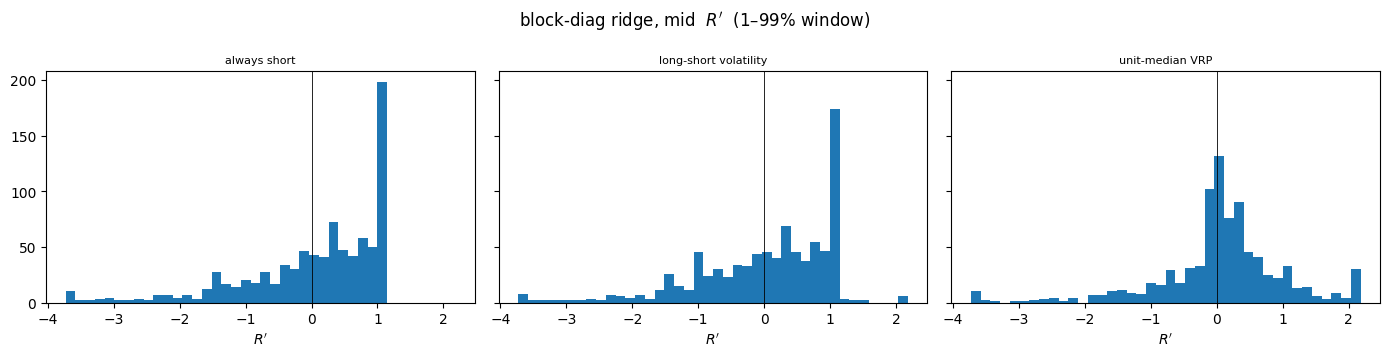

In [11]:
def causal_leverage(signal: pd.Series, cap: float = 3.0) -> pd.Series:
    med = signal.abs().expanding(min_periods=63).median().shift(1)
    lev = (signal.abs() / med).clip(upper=cap)
    return lev.fillna(1.0)


def rule_sizes(px: pd.DataFrame) -> dict[str, pd.Series]:
    lev = causal_leverage(px["signal"])
    return {
        "always short": pd.Series(-1.0, index=px.index),
        "long-short volatility": px["pos"],
        "unit-median VRP": px["pos"] * lev,
    }


def rule_row(r: pd.Series, size: pd.Series) -> pd.Series:
    r = pd.Series(r).astype(float)
    size = pd.Series(size, index=r.index).astype(float)
    x = r.dropna()
    n = int(len(x))
    mu = float(x.mean())
    sd = float(x.std(ddof=1))
    n_buy = int((size > 0).sum())
    n_sz = int(size.notna().sum())
    return pd.Series({
        "n": n,
        "mean": mu,
        "std": sd,
        "min": float(x.min()),
        "25%": float(x.quantile(0.25)),
        "50%": float(x.median()),
        "75%": float(x.quantile(0.75)),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "ex_kurt": float(x.kurt()),
        "t_mean": mu / sd * np.sqrt(n) if sd > 0 else float("nan"),
        "Sharpe_ann": mu / sd * np.sqrt(252.0) if sd > 0 else float("nan"),
        "n_buy": n_buy,
        "pct_buy": 100.0 * n_buy / n_sz if n_sz else float("nan"),
    })


order = [
    "always short",
    "long-short volatility",
    "unit-median VRP",
]
cols = ["n", "mean", "std", "min", "25%", "50%", "75%", "max",
        "skew", "ex_kurt", "t_mean", "Sharpe_ann", "n_buy", "pct_buy"]
MODEL_ORDER = ["a0", "blk2", "lgbm", "xgb", "lasso_t", "lasso_f", "enet"]

common = None
for tag in MODEL_ORDER:
    idx = books[tag].index
    common = idx if common is None else common.intersection(idx)
common = common.sort_values()
print("days per model:", {LABEL[t]: len(books[t]) for t in MODEL_ORDER})
print("common days:", len(common),
      pd.Timestamp(common.min()), "->", pd.Timestamp(common.max()))

rule_tabs = {}
for tag in MODEL_ORDER:
    px = books[tag]
    sizes = rule_sizes(px)
    rule_tabs[tag] = pd.DataFrame({
        name: rule_row((sizes[name] * px["R"]).loc[common], sizes[name].loc[common])
        for name in order
    }).T[cols]
    rule_tabs[tag].to_csv(OUT / f"rule_table_{tag}.csv")

for name in order:
    if name == "always short":
        # takes no forecast: every model row is identical, so print one
        # anonymous row (and assert the identity instead of trusting it)
        base = rule_tabs[MODEL_ORDER[0]].loc[name]
        for tag in MODEL_ORDER[1:]:
            assert np.allclose(rule_tabs[tag].loc[name], base), name
        tab = pd.DataFrame({"all models": base}).T[cols]
    else:
        tab = pd.DataFrame(
            {LABEL[tag]: rule_tabs[tag].loc[name] for tag in MODEL_ORDER}
        ).T[cols]
    print(name)
    print(tab.to_string())
    print("---")
    safe = "".join(ch if ch.isalnum() else "_" for ch in name)
    tab.to_csv(OUT / f"rule_by_strategy_{safe}.csv")
print("saved per-model rule_table_*.csv and per-rule rule_by_strategy_*.csv in", OUT)

fig, axes = plt.subplots(1, len(order), figsize=(14, 3.6), sharex=True, sharey=True)
px = books["blk2"]
sizes = rule_sizes(px)
pooled = pd.concat([sizes[name] * px["R"] for name in order], axis=0).dropna()
lo, hi = float(pooled.quantile(0.01)), float(pooled.quantile(0.99))
bins = np.linspace(lo, hi, 41)
for ax, name in zip(axes.ravel(), order):
    x = (sizes[name] * px["R"]).dropna()
    ax.hist(x.clip(lo, hi), bins=bins, color="C0", edgecolor="none")
    ax.axvline(0.0, color="k", lw=0.6)
    ax.set_title(name, fontsize=8)
    ax.set_xlabel(r"$R'$")
fig.suptitle("block-diag ridge, mid  $R'$  (1–99% window)")
fig.tight_layout()
fig.savefig(OUT / "rule_hists_blk2.png", dpi=120, bbox_inches="tight")
print("saved", OUT / "rule_hists_blk2.png")
display(fig)
plt.close(fig)


## Hand-check one row

- `K_c >= S` and `K_p <= S` at 15:30.
- `entry` = 15:30 `mid_c + mid_p`.
- `exit` = `max(S_close - K_c, 0) + max(K_p - S_close, 0)` with `S_close` from yfinance `^GSPC`.
- `R` = `exit/entry - 1`.
- `yhat` is $\widehat{\sqrt{RV/B}}$ (fit scale). `rv_hat=(m^2+s2)*B` is
  30-min variance.
- Quoted IV is hourly; `iv_30 = iv_hourly / sqrt(2)`, `iv_var = iv_30**2`.
- `signal = rv_hat - iv_var`. $\mathrm{VRP}=-s$. Long-short volatility `pos` is
  $+1$ if signal $> 0$, else $-1$. Unit-median VRP is
  $q_t=s_t/\mathrm{med}_{u<t}|s_u|$.